# Beyond BLAST

In [3]:
using Pkg
Pkg.activate("blast_code")
Pkg.resolve()
Pkg.instantiate()

  Activating project at `~/Desktop/cosmo/notebooks/blast_code`
  No Changes to `~/Desktop/cosmo/notebooks/blast_code/Project.toml`
  No Changes to `~/Desktop/cosmo/notebooks/blast_code/Manifest.toml`


In [4]:
include("blast_code/src/Blast.jl")
include("blast_code/src/blast_tutorials.jl")
include("blast_code/src/new_funcs.jl");

In [34]:
using NPZ
using DataInterpolations
using Interpolations
using FastChebInterp
using BenchmarkTools
using FFTW
using Plots
using QuadGK
using LaTeXStrings
using Tullio
using LoopVectorization
using LinearAlgebra
using Unitful
using Revise
using SpecialFunctions
using DifferentialEquations
using Cosmology
using NumericalIntegration
using .Blast
using .blast_tutorials;

### Computing background quantities:

redshift $z$, comoving distance $\chi(z)$

In [84]:
#Background quantities
z_b = npzread("blast_code/data/background/z.npy") # array 
χ_b = npzread("blast_code/data/background/chi.npy") # array 
# below: approximate the redshift z as a function of the comoving distance χ, 
# and vice versa, using Akima interpolation
z_of_χ = DataInterpolations.AkimaInterpolation(z_b, χ_b); # z(χ)
χ_of_z = DataInterpolations.AkimaInterpolation(χ_b, z_b); # χ(z)
println("Redshift range: ", first(z_b), " ", last(z_b))
println("Comoving distance range: ", first(χ_b), " ", last(χ_b))
println("Interpolated redshifts: ", first(z_of_χ.(χ_b)), " ", last(z_of_χ.(χ_b)))
println("Interpolated comoving distances: ", first(χ_of_z.(z_b)), " ", last(χ_of_z.(z_b)))

Redshift range: 0.0 100.0
Comoving distance range: 0.0 12830.219503765933
Interpolated redshifts: 0.0 100.0
Interpolated comoving distances: 0.0 12830.219503765933


N5K bins: ["dNdz_cl", "z_sh", "dNdz_sh", "z_cl"]
N5K dN/dz (clustering): 
(2000, 10)
9.518772964715878e-8 9.989934505901335e-264


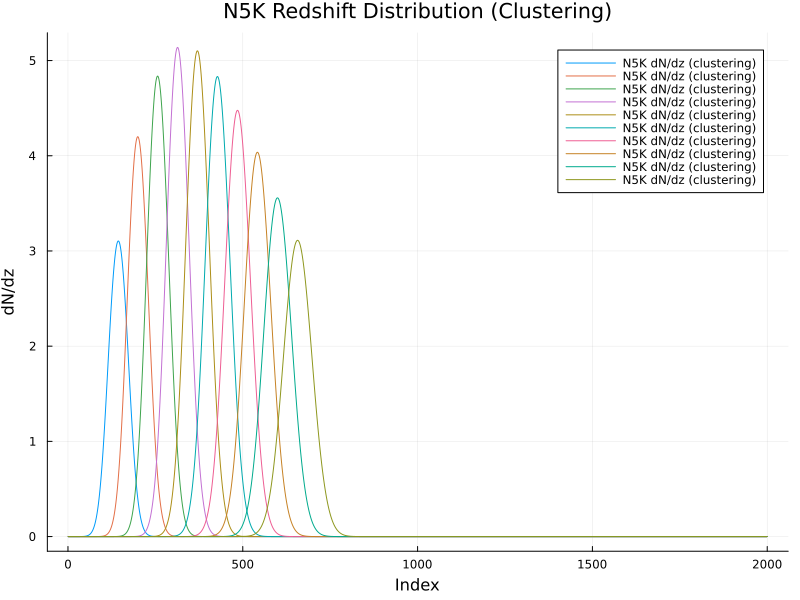

In [94]:
# Load N5K n(z), needed to compute lensing and clustering kernels
n5k_bins = npzread("blast_code/data/dNdzs_fullwidth.npz")
println("N5K bins: ", keys(n5k_bins))
println("N5K dN/dz (clustering): ")
println(size(n5k_bins["dNdz_cl"]))
println(first(n5k_bins["dNdz_cl"]), " ", last(n5k_bins["dNdz_cl"]))
plot(n5k_bins["dNdz_cl"], 
     label="N5K dN/dz (clustering)", 
     xlabel="Index", 
     ylabel="dN/dz", 
     title="N5K Redshift Distribution (Clustering)",
     size=(800,600))

In [248]:
# A_tot = integrate(z_array, dNdz, Trapezoidal()) # total area under the n(z) curve
# n_z_array = dNdz ./ A_tot # normalize n(z)
#### REDSHIFT DISTRIBUTION
dNdz = vec(n5k_bins["dNdz_cl"])# array of n(z) values corresponding to the redshifts in z_array
println("dNdz is a vector or dimension: ", size(dNdz))
#### REDSHIFT ARRAY
z_array = LinRange(0.0, 3.0, length(dNdz)) # array of redshifts to evaluate n(z) on
#### COMOVING DISTANCES ARRAY
chi_array = χ_of_z.(z_array) # array of comoving distances corresponding to z_array
println("z_array is a vector or dimension: ", size(z_array))
#### NORMALIZATION OF n(z) FOR EACH BIN
n_bins = 10 # if galaxy clustering, otherwise n_bins = 5 for shear-shear and n_bins = 10 for galaxy-shear
nz_norm = zeros(n_bins) # array to hold the normalized n(z) for each bin
for b in 1:n_bins
  nz_func = DataInterpolations.AkimaInterpolation(dNdz, z_array, extrapolation=ExtrapolationType.Linear)
  nz_norm[b], _ = quadgk(x->nz_func(x), first(z_array), last(z_array))
end
println("nz_norm is a vector or dimension: ", size(nz_norm))
println("Normalized n(z) for each bin: ")
for b in 1:n_bins
  println("Bin $b: $(nz_norm[b])")
end
println("Not Normalized n(z) for each bin: ")
for b in 1:n_bins
  println("Bin $b: $(dNdz[b])")
end
println("n_z_array is a vector or dimension: ", size(n_z_array))

# plot(z_array, n_z_array, label="N5K dN/dz", xlabel="Redshift z", ylabel="dN/dz", title="Normalized Redshift Distribution")
# plot!(z_array, dNdz, label="N5K dN/dz (unnormalized)", xlabel="Redshift z", ylabel="dN/dz", title=L"$n(z)$ (Normalized vs Unnormalized)")

dNdz is a vector or dimension: (20000,)
z_array is a vector or dimension: (20000,)
nz_norm is a vector or dimension: (10,)
Normalized n(z) for each bin: 
Bin 1: 0.5406287686314523
Bin 2: 0.5406287686314523
Bin 3: 0.5406287686314523
Bin 4: 0.5406287686314523
Bin 5: 0.5406287686314523
Bin 6: 0.5406287686314523
Bin 7: 0.5406287686314523
Bin 8: 0.5406287686314523
Bin 9: 0.5406287686314523
Bin 10: 0.5406287686314523
Not Normalized n(z) for each bin: 
Bin 1: 9.518772964715878e-8
Bin 2: 1.2459990855190674e-7
Bin 3: 1.6273109249490808e-7
Bin 4: 2.1205079767967573e-7
Bin 5: 2.756933804705729e-7
Bin 6: 3.5762703309454306e-7
Bin 7: 4.628629737138614e-7
Bin 8: 5.977136616057047e-7
Bin 9: 7.701106251439018e-7
Bin 10: 9.89994553113157e-7
n_z_array is a vector or dimension: (20000,)


In [103]:
println("First and last values of n_z_array: ", first(n_z_array), " ", last(n_z_array))
println("Dimension of n_z_array: ", size(n_z_array)[1])
println("First and last values of nz_norm: ", first(nz_norm), " ", last(nz_norm))
println("Dimension of nz_norm: ", size(nz_norm)[1])

First and last values of n_z_array: 1.760685652122688e-7 1.8478363141326217e-263
Dimension of n_z_array: 20000
First and last values of nz_norm: 0.5406287686314523 0.5406287686314523
Dimension of nz_norm: 10


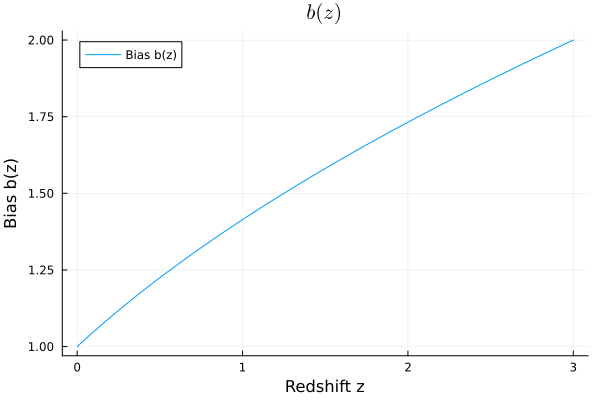

In [19]:
# compute the bias. the equation is b(z) = b_0 * sqrt(1+z). we set b_0 = 1.0.!
b_0 = 1.0
b_z_array = b_0 .* sqrt.(1 .+ z_array) # bias as a function of redshift
plot(z_array, b_z_array, label="Bias b(z)", xlabel="Redshift z", ylabel="Bias b(z)", title=L"$b(z)$")

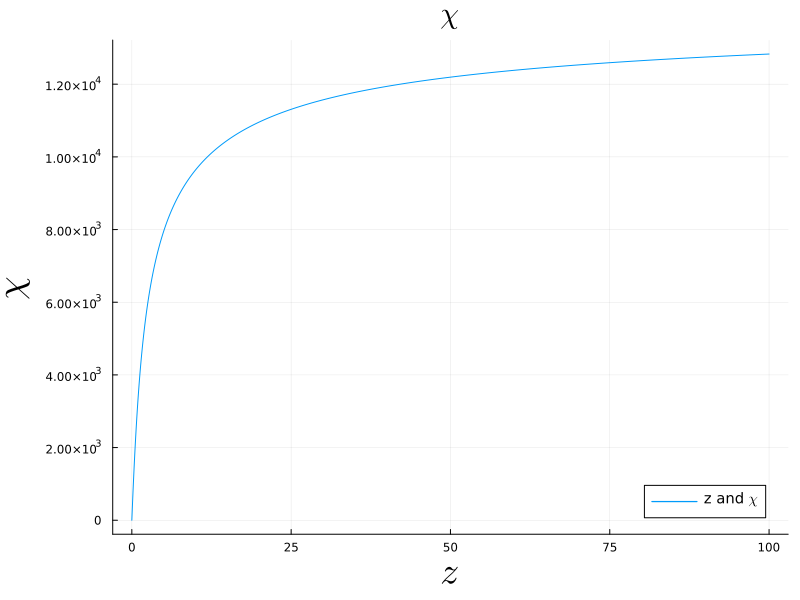

In [20]:
plot(z_b, χ_b, label=L"z and $\chi$", 
               title = L"$\chi$", 
               titlefontsize=20, 
               xlabel=L"$z$", 
               ylabel=L"$\chi$", 
               labelfontsize=25,
               legendfontsize=10,
               size=(800,600))

First and last values of z_range: 0.005829802271562456 3.5484647664654276
First and last values of growth_array: 1.0 0.31527182399922954


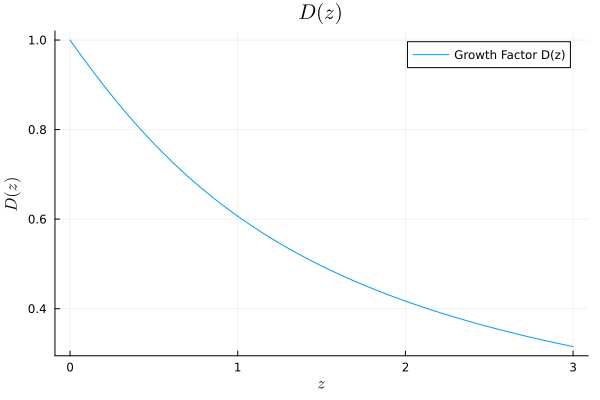

In [106]:
#i want to obtain the growth factor D(z) from the background quantities. i can use the cosmology package to compute this.
cosmo = Blast.FlatΛCDM()
# Number of comoving distance points
nχ = 96
# Array of comoving distances
χ = LinRange(26, 7000, nχ)
# Array of redshifts corresponding to the comoving distances
z_range = z_of_χ.(χ)
println("First and last values of z_range: ", first(z_range), " ", last(z_range))

function heath_integral(cosmo, z)
    integrand(zp) = (1.0 + zp) / (Blast.compute_adimensional_hubble_factor(zp, cosmo)^3)
    integral_val, _ = quadgk(integrand, z, Inf, rtol=1e-8)
    return Blast.compute_adimensional_hubble_factor(z, cosmo) * integral_val
end
function compute_growth_factor(cosmo, z_array)
    D_unnorm_z0 = heath_integral(cosmo, 0.0)
    D_array = [heath_integral(cosmo, zz) / D_unnorm_z0 for zz in z_array]
    return D_array
end
# Array of growth factor values
growth_array = compute_growth_factor(cosmo, z_array)
println("First and last values of growth_array: ", first(growth_array), " ", last(growth_array))
# for (z, D) in zip(z_array, growth_array)
#     println("z = $z -> D(z) = $(round(D, digits=5))")
# end
plot(z_array, growth_array, label="Growth Factor D(z)", xlabel=L"$z$", ylabel=L"$D(z)$", title=L"$D(z)$")

In [108]:
println("First and last values of z_range: ", first(z_range), " ", last(z_range))
println("Dimension of z_range: ", size(z_range)[1])
println("First and last values of z_array: ", first(z_array), " ", last(z_array))
println("Dimension of z_array: ", size(z_array)[1])

First and last values of z_range: 0.005829802271562456 3.5484647664654276
Dimension of z_range: 96
First and last values of z_array: 0.0 3.0
Dimension of z_array: 20000


Size of array: chi(z): 20000
Size of array: b(z): 20000
Size of array: D(z): 20000
Size of array: n(z): 20000
Size of array: dNdz: 20000


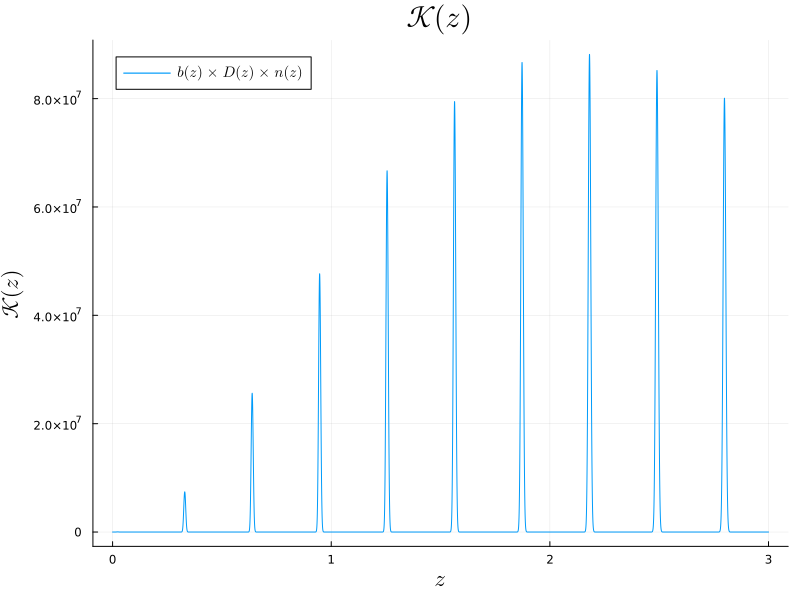

In [125]:
# here i compute the quantity that multiplies the comoving distance, the bias factor, the growth factor, the density n(z)
#kernel_composed = chi_array .* chi_array .* b_z_array .* growth_array .* n_z_array
kernel_composed = chi_array .* chi_array .* b_z_array .* growth_array .* dNdz
println("Size of array: chi(z): ", size(chi_array)[1])
println("Size of array: b(z): ", size(b_z_array)[1])
println("Size of array: D(z): ", size(growth_array)[1])
println("Size of array: n(z): ", size(n_z_array)[1])
println("Size of array: dNdz: ", size(dNdz)[1])
plot(z_array, kernel_composed, 
     label=L"$b(z) \times D(z) \times n(z)$", 
     xlabel=L"$z$", 
     ylabel=L"\mathcal{K}(z)", 
     title=L"\mathcal{K}(z)",
     labelfont=20,
     labelcolor=:blue,
     titlefontsize=20, 
     xlabelfontsize=15,
     ylabelfontsize=15,
     legendfontsize=10,
     size=(800,600))

In [53]:
#3D matter power spectrum
pk_dict = npzread("blast_code/data/pk.npz")
Pklin = pk_dict["pk_lin"]
Pknonlin = pk_dict["pk_nl"]
k = pk_dict["k"]
z = pk_dict["z"];

In [148]:
println("Dimension of k points: ", size(k)[1])
println("Dimension of Pklin: ", size(Pklin)[1])
println("Dimension of Pknonlin: ", size(Pknonlin)[1])

Dimension of k points: 200
Dimension of Pklin: 50
Dimension of Pknonlin: 50


In [196]:
#Interpolating the power spectrum
#Linear P(k)
# y has the same length as k, and is a logarithmic range from log10(first(k)) to log10(last(k))
y = LinRange(log10(first(k)),log10(last(k)), length(k))
# x has the same length as z, and is a linear range from first(z) to last(z)
x = LinRange(first(z), last(z), length(z))

# this creates an interpolation of the linear P(k) data. 
# the interpolatio is in log space because P(k) changes by many order or magnitude
InterpPmm = Interpolations.interpolate(log10.(Pklin),BSpline(Cubic(Line(OnGrid()))))
# this scales the interpolation to the x and y ranges defined above, 
# so that we can evaluate it at any (z, log10(k)) within those ranges
InterpPmm = scale(InterpPmm, (x, y))
# this allows us to extrapolate the interpolation outside of the defined x and y ranges
InterpPmm = Interpolations.extrapolate(InterpPmm, Line())

#Non-linear P(k) - similar to the linear P(k)
y = LinRange(log10(first(k)),log10(last(k)), length(k))
x = LinRange(first(z), last(z), length(z))
InterpPmm_nl = Interpolations.interpolate(log10.(Pknonlin),BSpline(Cubic(Line(OnGrid()))))
InterpPmm_nl = scale(InterpPmm_nl, x, y)
InterpPmm_nl = Interpolations.extrapolate(InterpPmm_nl, Line())

#Callables: these functions take in k, χ1, and χ2, 
# and return the square root of the product of the P(k) evaluated at those points.
power_spectrum(k, χ1, χ2) = @. sqrt(10^InterpPmm(z_of_χ(χ1),log10(k)) * 10^InterpPmm(z_of_χ(χ2),log10(k)))
power_spectrum_nl(k, χ1, χ2) = @. sqrt(10^InterpPmm_nl(z_of_χ(χ1),log10(k)) * 10^InterpPmm_nl(z_of_χ(χ2),log10(k)));

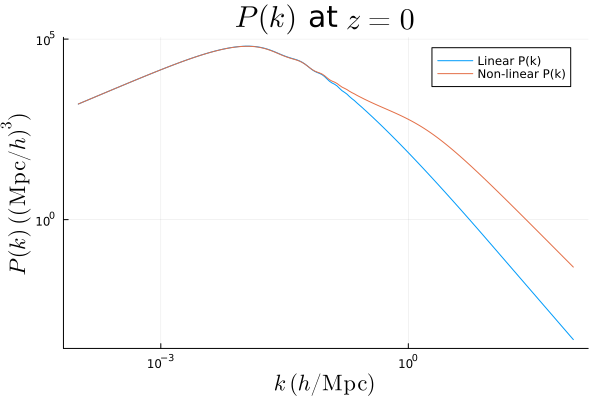

In [55]:
plot(k, power_spectrum.(k, 1000.0, 1000.0), 
     label="Linear P(k)", 
     xscale=:log10, 
     yscale=:log10, 
     title=L"$P(k)$ at $z=0$", titlefontsize=20,
     xlabel=L"$k \; (h/\mathrm{Mpc})$", 
     ylabel=L"$P(k) \; ((\mathrm{Mpc}/h)^3)$", 
     labelfontsize=15)
plot!(k, power_spectrum_nl.(k, 1000.0, 1000.0), 
      label="Non-linear P(k)", 
      xscale=:log10, 
      yscale=:log10)

In [56]:
#N5K benchmarks
dtype = Float64

benchmark_gg = npzread("blast_code/data/benchmarks_nl_full_clgg.npz")
benchmark_ll = npzread("blast_code/data/benchmarks_nl_full_clss.npz")
benchmark_gl = npzread("blast_code/data/benchmarks_nl_full_clgs.npz")

#Extracting C_ℓ
gg = dtype.(benchmark_gg["cls"])
ll = dtype.(benchmark_ll["cls"])
gl = dtype.(benchmark_gl["cls"])
ell = dtype.(benchmark_gg["ls"])

#Reshaping them into the same Blast's format
gg_reshaped = zeros( dtype, length(ell), 10, 10)
ll_reshaped = zeros(dtype, length(ell), 5, 5)
gl_reshaped = zeros( dtype, length(ell), 10, 5)
counter = 1
for i in 1:10
    for j in i:10
        gg_reshaped[:,i,j] = gg[counter, :]
        gg_reshaped[:,j,i] = gg_reshaped[:,i,j]
        counter += 1
    end
end
counter = 1
for i in 1:5
    for j in i:5
        ll_reshaped[:,i,j] = ll[counter, :]
        ll_reshaped[:,j,i] = ll_reshaped[:,i,j]
        counter += 1
    end
end
counter = 1
for i in 1:10
    for j in 1:5
        gl_reshaped[:,i,j] = gl[counter, :]
        counter += 1
    end
end

In [ ]:
ℓ = Blast.ℓ
n_chi = 96                                            # number of comoving "bins"
x_min = 26                                            # minimum comoving distance
x_max = 7000                                          # maximum comoving distance
χ = LinRange(x_min, x_max, n_chi)                     # array of comoving distances
R = chebpoints(n_chi, -1, 1)                          # array of ratios between comoving distances
R = reverse(R[R.>0])
nR = length(R)                                        # number of ratios R
kmax = 200/13                                         # maximum wavenumber (small scales)
kmin = 2.5/x_max                                      # minimum wavenumber (large scales)
n_cheb = 119                                          # number of Chebyshev nodes 
β = 2                                                 # exponent depending on the probe: 0 for Galaxy - Shear, 2 for Galaxy - Galaxy, -2 for Shear - Shear
k_cheb = chebpoints(n_cheb, log10(kmin), log10(kmax)) # number of Chebyshev "points"
N = 2^(15)+1;                                         # number of integration points


# Define k' and k'' on Chebyshev grid
#k1 = k2 = 10 .^ chebpoints(n_cheb, log10(kmin), log10(kmax)) # wavenumbers k' and k''

In [203]:
# I choose a grid of Chebyshev nodes in z, which I will use to evaluate 
# the kernels and the power spectrum.
zmin = first(z_range)
zmax = last(z_range)

t_of_z(z) = (2*z - (zmax + zmin)) / (zmax - zmin)
z_of_t(t) = (zmin + zmax)/2 + (zmax - zmin)/2 * t

j = 1:n_cheb
t_nodes = cos.((2 .* j .- 1) .* pi ./ (2*n_cheb))     # size N, in [-1,1]
z_nodes = z_of_t.(t_nodes)                            # Chebyshev nodes in z

println("First Chebyshev node in z: ", z_nodes[1])
println("Last Chebyshev node in z: ", z_nodes[end])
println("-------")
println("First Chebyshev node in t: ", t_nodes[1])
println("Last Chebyshev node in t: ", t_nodes[end])

First Chebyshev node in z: 3.5483104522487574
Last Chebyshev node in z: 0.005984116488232383
-------
First Chebyshev node in t: 0.9999128816724107
Last Chebyshev node in t: -0.9999128816724107


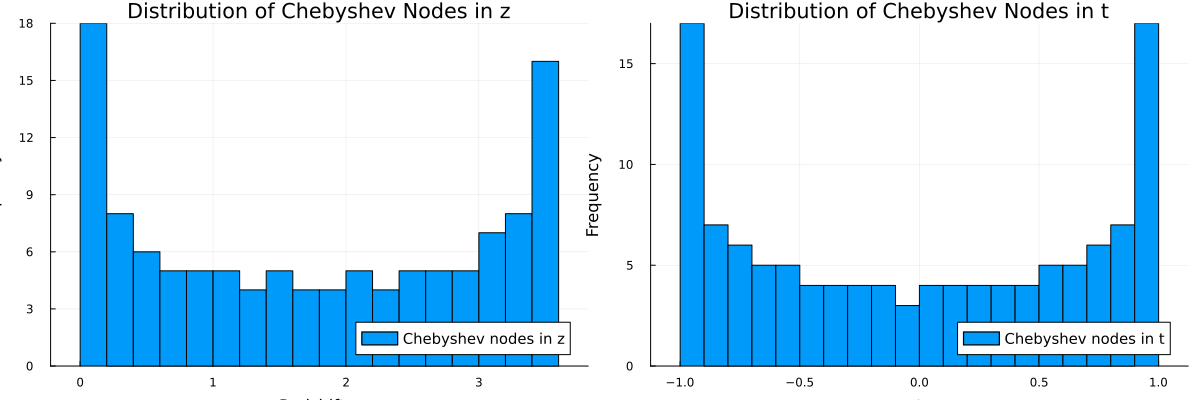

In [204]:
h1 = histogram(z_nodes, bins=20, 
               label="Chebyshev nodes in z", 
               xlabel="Redshift z", 
               ylabel="Frequency", 
               title="Distribution of Chebyshev Nodes in z",
               legendfontsize=10,
               legend=:bottomright)
h2 = histogram(t_nodes, bins=20, 
               label="Chebyshev nodes in t", 
               xlabel="t", 
               ylabel="Frequency", 
               title="Distribution of Chebyshev Nodes in t",
               legendfontsize=10,
               legend=:bottomright)
plot(h1, h2, layout=(1,2), size=(1200,400))

In [ ]:
# build simple interpolants for b, D, n defined on z_array
b_interp = extrapolate(interpolate((z_array,), b_z_array, Gridded(Linear())), Line())
D_interp = extrapolate(interpolate((z_array,), growth_array, Gridded(Linear())), Line())
n_interp = extrapolate(interpolate((z_array,), n_z_array, Gridded(Linear())), Line())
println("Max of n_interp: ", maximum(n_interp))
println("Min of n_interp: ", minimum(n_interp))
# evaluate χ at Chebyshev z_nodes (χ_of_z from your Akima interp)
χ_nodes = χ_of_z.(z_nodes)
# combined kernel at nodes
K_nodes = χ_nodes .^ 2 .* b_interp.(z_nodes) .* D_interp.(z_nodes) .* n_interp.(z_nodes)
planK = Blast.plan_fft(K_nodes)
K_cheb_coeff = Blast.fast_chebcoefs(K_nodes, planK)
println("Chebyshev coefficients: ", K_cheb_coeff)
println("Max of K_cheb_coeff: ", maximum(K_cheb_coeff))
println("Min of K_cheb_coeff: ", minimum(K_cheb_coeff))

Max of n_interp: 2.0610871743379666e-31
Min of n_interp: -3.703213489824381e-255
Chebyshev coefficients: [1.8016785309380835e6, 483554.7817050768, -3.015769022038776e6, -1.1997548747711717e6, 2.1110264772287444e6, 1.150924411071291e6, -1.8817716722579938e6, -637052.5261844391, 2.1194929773731176e6, 771334.6632125521, -2.314912151657543e6, -1.607040668393994e6, 2.1659242441649972e6, 2.0204005999090367e6, -1.5425194760229052e6, -1.7975902727046052e6, 1.103646824899779e6, 1.632397699442264e6, -1.4349212327424518e6, -1.786139385661268e6, 1.7203172140209759e6, 2.2247184869352384e6, -1.1825930615685661e6, -2.6564566209394312e6, 468643.30779717537, 2.4596137716666902e6, -298904.19266149466, -1.8877105593615628e6, 478262.50465547165, 2.09180082285221e6, -626261.6088162884, -2.9955142480628076e6, 223600.375059497, 3.4091667096248735e6, 925568.5681684883, -2.9791431485506617e6, -1.8296264609712816e6, 2.218439779614408e6, 1.6181444053158148e6, -1.6287978191870442e6, -1.0970399804059383e6, 1.68606

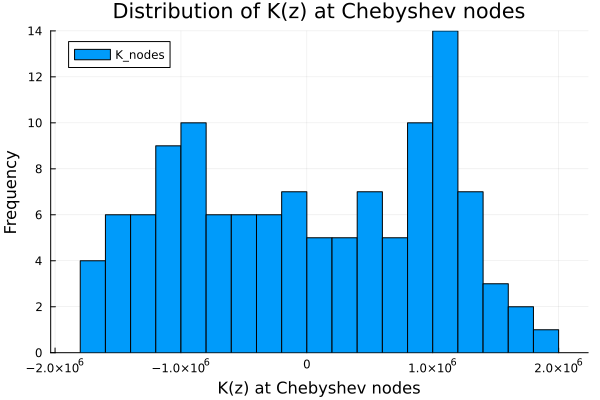

In [240]:
histogram(K_cheb_coeff, bins=20, label="K_nodes", xlabel="K(z) at Chebyshev nodes", ylabel="Frequency", title="Distribution of K(z) at Chebyshev nodes")

In [242]:
println("Dimension of b_interpolant: ", size(b_interp)[1])
println("First value of b_interpolant at nodes: ", b_interp.(z_nodes)[1])
println("Last value of b_interpolant at nodes: ", b_interp.(z_nodes)[end])
println("-----")
println("Dimension of D_interpolant: ", size(D_interp)[1])
println("First value of D_interpolant at nodes: ", D_interp.(z_nodes)[1])
println("Last value of D_interpolant at nodes: ", D_interp.(z_nodes)[end])
println("-----")
println("Dimension of n_interpolant: ", size(n_interp)[1])
println("First value of n_interpolant at nodes: ", n_interp.(z_nodes)[1])
println("Last value of n_interpolant at nodes: ", n_interp.(z_nodes)[end])
println("-----")
println("Dimension of z_nodes: ", size(z_nodes)[1])
println("First value of z_nodes: ", z_nodes[1])
println("Last value of z_nodes: ", z_nodes[end])
println("-----")
println("Dimension of χ_nodes: ", size(χ_nodes)[1])
println("First value of χ_nodes: ", χ_nodes[1])
println("Last value of χ_nodes: ", χ_nodes[end])
println("-----")
println("Dimension of K_nodes: ", size(K_nodes)[1])
println("First value of K_nodes: ", K_nodes[1])
println("Last value of K_nodes: ", K_nodes[end])
println("-----")
println("Dimension of Chebyshev coefficients: ", size(K_cheb_coeff)[1])
println("First value of Chebyshev coefficients: ", K_cheb_coeff[1])
println("Last value of Chebyshev coefficients: ", K_cheb_coeff[end])
println("-----")

Dimension of b_interpolant: 20000
First value of b_interpolant at nodes: 2.1370788982533897
Last value of b_interpolant at nodes: 1.002987595112714
-----
Dimension of D_interpolant: 20000
First value of D_interpolant at nodes: 0.2728323311304118
Last value of D_interpolant at nodes: 0.9968458932837158
-----
Dimension of n_interpolant: 20000
First value of n_interpolant at nodes: -5.48858675706088e-260
Last value of n_interpolant at nodes: 0.000770661241504901
-----
Dimension of z_nodes: 119
First value of z_nodes: 3.5483104522487574
Last value of z_nodes: 0.005984116488232383
-----
Dimension of χ_nodes: 119
First value of χ_nodes: 6999.870114443534
Last value of χ_nodes: 26.643271327792124
-----
Dimension of K_nodes: 119
First value of K_nodes: -1.5680390944396498e-252
Last value of K_nodes: 0.5469683522043215
-----
Dimension of Chebyshev coefficients: 119
First value of Chebyshev coefficients: 974039.2256122852
Last value of Chebyshev coefficients: -557616.2092488806
-----


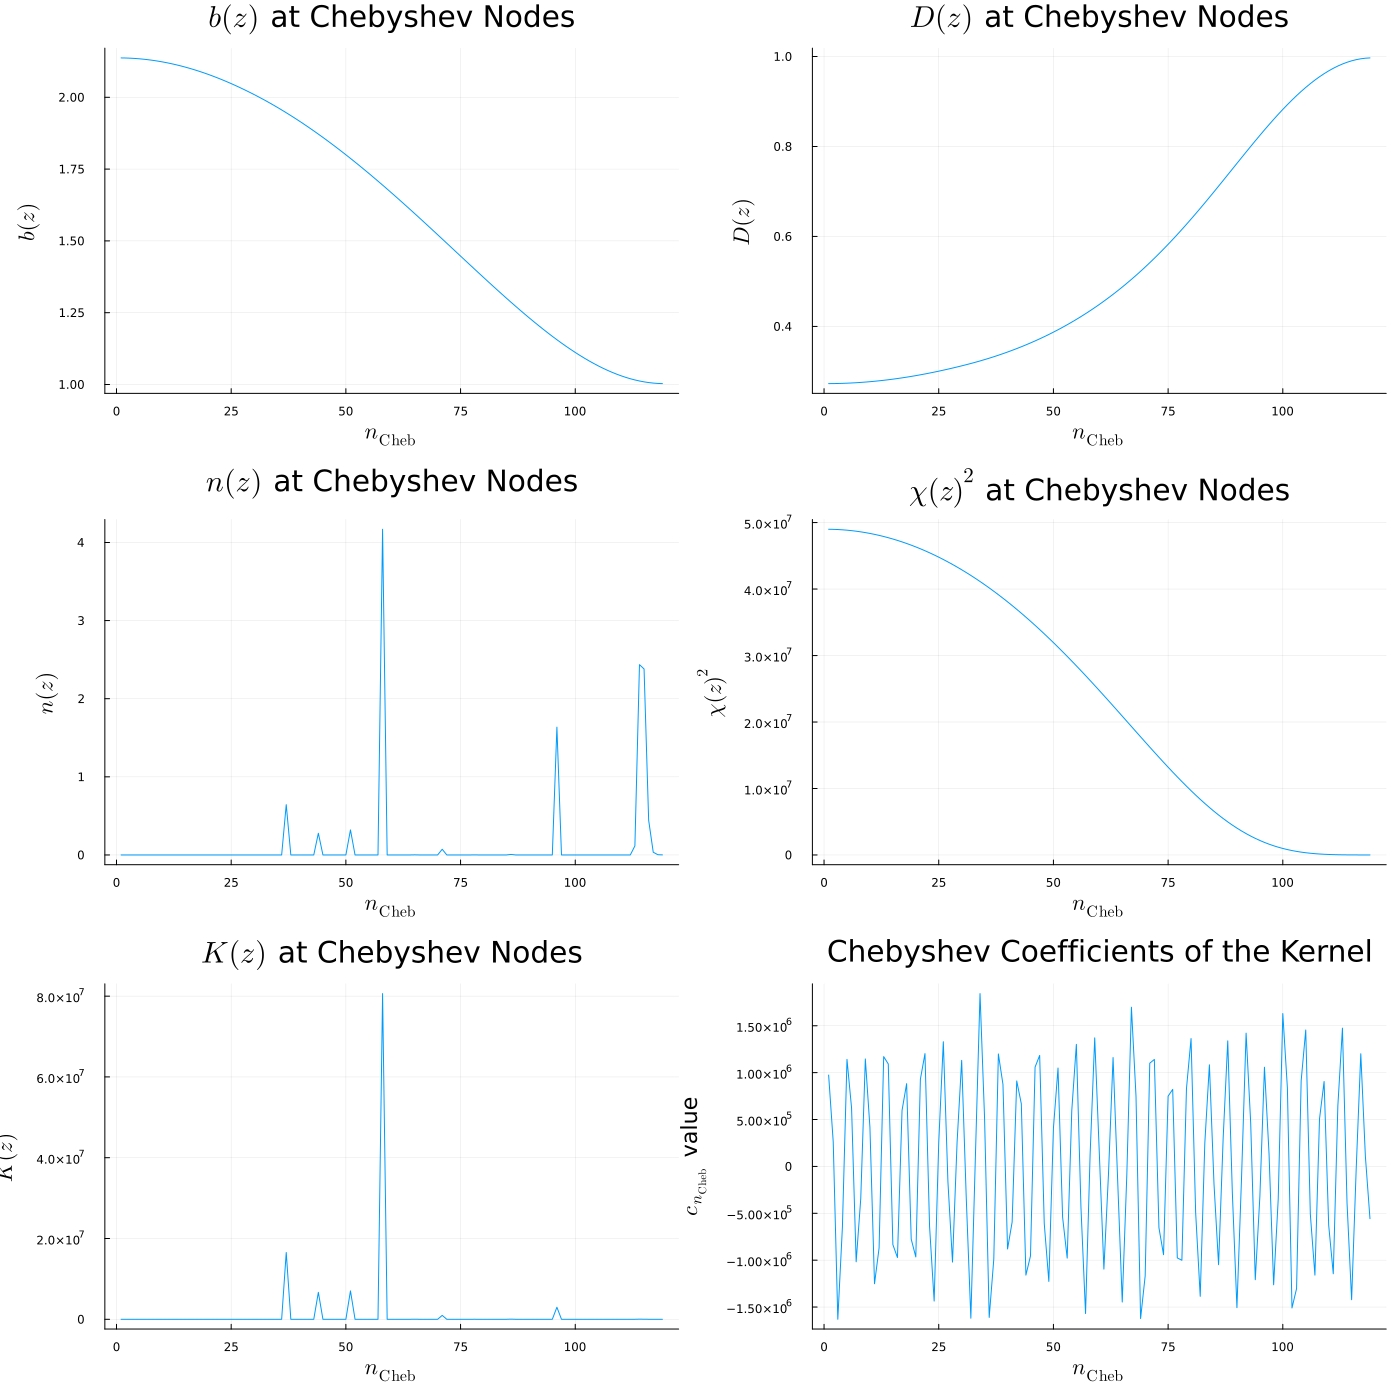

In [236]:
#create a plot of 6 plots: b_interp, D_interp, n_interp, χ_nodes^2, K_nodes, and the Chebyshev coefficients c, all evaluated at the Chebyshev nodes z_nodes.
p1 = plot(1:length(K_cheb_coeff), b_interp.(z_nodes),
    label="b_interp at nodes",
    xlabel=L"$n_{\mathrm{Cheb}}$", ylabel=L"$b(z)$",
    title=L"$b(z)$ at Chebyshev Nodes"
    )
p2 = plot(1:length(K_cheb_coeff), D_interp.(z_nodes),
    label="D_interp at nodes",
    xlabel=L"$n_{\mathrm{Cheb}}$", ylabel=L"$D(z)$",
    title=L"$D(z)$ at Chebyshev Nodes"
    )
p3 = plot(1:length(K_cheb_coeff), n_interp.(z_nodes),
    xlabel=L"$n_{\mathrm{Cheb}}$", ylabel=L"$n(z)$",
    title=L"$n(z)$ at Chebyshev Nodes"
    )
p4 = plot(1:length(K_cheb_coeff), χ_nodes .^ 2,
    label="χ_nodes^2",
    xlabel=L"$n_{\mathrm{Cheb}}$", ylabel=L"$\chi(z)^2$",
    title=L"$\chi(z)^2$ at Chebyshev Nodes"
    )
p5 = plot(1:length(K_cheb_coeff), K_nodes,
    label="K_nodes",
    xlabel=L"$n_{\mathrm{Cheb}}$", ylabel=L"$K(z)$",
    title=L"$K(z)$ at Chebyshev Nodes"
    )
p6 = plot(1:length(K_cheb_coeff), K_cheb_coeff,
    label="Chebyshev coefficients",
    xlabel=L"$n_{\mathrm{Cheb}}$", ylabel=L"$c_{n_{\mathrm{Cheb}}}$ value",
    title="Chebyshev Coefficients of the Kernel",
    )

plot(p1, p2, p3, p4, p5, p6, layout=(3,2), size=(1400,1400), legend=false, labelfont=15, titlefontsize=20, xlabelfontsize=15, ylabelfontsize=15)
